Catherine Carmosino

11/15/2025

# Loading in the Data

In [1]:
# Core libraries
#the package imports we need
import hisepy
import scanpy as sc
import pandas as pd
import numpy as np

#for visualizations
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:788: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\sum_{ij} \\left(A_{ij} - \\gamma \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:27: SyntaxWarning: invalid escape sequence '\g'
  implementation therefore does not guarantee subpartition :math:`\gamma`-density.
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:346: SyntaxWarning: invalid escape sequence '\s'
  .. math:: Q = \sum_k \\lambda_k Q_k.


In [2]:
#importing the data file
h5ad_files = hisepy.cache_fileset('f48bf688-1a5f-456c-b0b0-c6ec870ec003')

In [3]:
#looking at the first 5 file names
h5ad_files[0:5]

['/home/workspace/input/1784782472/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Afatinib_BIBW2992_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1784782472/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Afatinib_dimaleate_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1784782472/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Baricitinib_LY3009104_INCB028050_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1784782472/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Baricitinib_phosphate_counts_filtered_labeled_sampled.h5ad',
 '/home/workspace/input/1784782472/fileset/f48bf688-1a5f-456c-b0b0-c6ec870ec003/rhodium-niobium-silver/Canertinib_CI-1033_counts_filtered_labeled_sampled.h5ad']

# Looking at the AnnData frame

In [4]:
#creating a list
adata_list = []

#looping through the file names
for h5ad_file in h5ad_files:
    #read the file into an AnnData object using scanpy
    adata = sc.read_h5ad(h5ad_file)
    #appending the AnnData file into the list
    adata_list.append(adata)

In [5]:
#looking at the first 2 AnnData objects in the list
adata_list[0:2]

[AnnData object with n_obs × n_vars = 25000 × 1916
     obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
     uns: 'drug_name_colors', 'leiden_2', 'neighbors', 'pca', 'umap'
     obsm: 'X_pca', 'X_umap'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 25000 × 1916
     obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
     uns: 'drug_name_colors', 'leiden_2', 'neighbors', 'pca', 'umap'
     obsm: 'X_pca', 'X_um

In [6]:
#concatenating/combining all of the AnnData objects into one
adata = sc.concat(adata_list)

#make sure all observations are unique
adata.obs_names_make_unique()

#show how many cells there are per drug name
print(adata.obs["drug_name"].value_counts())

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/anndata/_core/merge.py:1667: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  concat_annot = pd.concat(


drug_name
Afatinib (BIBW2992)                    25000
Afatinib dimaleate                     25000
Baricitinib (LY3009104, INCB028050)    25000
Baricitinib phosphate                  25000
Canertinib (CI-1033)                   25000
Canertinib dihydrochloride             25000
DMSO Control                           25000
Erlotinib                              25000
Erlotinib Hydrochloride                25000
Gefitinib (ZD1839)                     25000
Gefitinib hydrochloride                25000
IL6 Control                            25000
NVP-BSK805                             25000
NVP-BSK805 2HCl                        25000
Ruxolitinib (INCB018424)               25000
Ruxolitinib phosphate                  25000
Tofacitinib (CP-690550) Citrate        25000
Tofacitinib (CP-690550,Tasocitinib)    25000
Name: count, dtype: int64


**From running `ad.concat()` there are 25,000 cells per sample.**

In [7]:
#seeing how many files are in the list
print(f"Length of adata_list is {len(adata_list)}")

adata

Length of adata_list is 18


AnnData object with n_obs × n_vars = 450000 × 1916
    obs: 'original_barcodes', 'batch_id', 'pool_id', 'chip_id', 'well_id', 'n_umis', 'n_genes', 'plate_location', 'cyto_treatment', 'drug_treatment', 'drug_name', 'drug_cas_number', 'drug_mw', 'drug_solvent', 'drug_pathway', 'drug_target', 'drug_description', 'drug_chembl_name', 'drug_chembl_id', 'AIFI_L1', 'AIFI_L2', 'leiden_2'
    obsm: 'X_pca', 'X_umap'

**The data contains 25,000 cells per sample, 18 samples (for 8 drugs with 2 formulas each and 2 controls), 450,000 observations (total cells), and 1,916 measured genes.**

In [8]:
#creating a copy of the data above so any manipulations done won't affect the original data
obs = adata.obs.copy()

In [9]:
obs[['AIFI_L2']].value_counts()

AIFI_L2            
CD4 Naive              118058
CD4 Central Memory     107272
CD8 Naive               78553
CD4 Effector Memory     49677
CD8 Effector Memory     39593
CD8 Central Memory      25655
Treg                    22905
MAIT                     8262
CD8aa                      25
Name: count, dtype: int64

**Out of the cell labels/types (from the 'AIFI_L2' column) the CD8aa is SIGNIFICANTLY less annotated than the other cells. MAIT is also lower than the rest by a factor of 10.**

In [10]:
obs[['drug_name']].value_counts()

drug_name                          
Afatinib (BIBW2992)                    25000
Afatinib dimaleate                     25000
Baricitinib (LY3009104, INCB028050)    25000
Baricitinib phosphate                  25000
Canertinib (CI-1033)                   25000
Canertinib dihydrochloride             25000
DMSO Control                           25000
Erlotinib                              25000
Erlotinib Hydrochloride                25000
Gefitinib (ZD1839)                     25000
Gefitinib hydrochloride                25000
IL6 Control                            25000
NVP-BSK805                             25000
NVP-BSK805 2HCl                        25000
Ruxolitinib (INCB018424)               25000
Ruxolitinib phosphate                  25000
Tofacitinib (CP-690550) Citrate        25000
Tofacitinib (CP-690550,Tasocitinib)    25000
Name: count, dtype: int64

**Out of the drugs (from the 'drug_name' column) all of them have the same amount of samples: 25,000**

In [11]:
obs[['drug_treatment']].value_counts()

drug_treatment
DMSO              50000
A1845             25000
A3012             25000
A3222             25000
A3145             25000
A3397             25000
A3433             25000
A3675             25000
A3276             25000
A3781             25000
A4135             25000
A4141             25000
A4138             25000
A4148             25000
A8219             25000
A8234             25000
A8247             25000
Name: count, dtype: int64

**Out of the drugs (from the 'drug_treatment' column) all of them have the same amount of samples: 25,000 EXCEPT the DMSO contol which has double that amount: 50,000**

In [12]:
print(f"There are {len(obs[['drug_treatment']].value_counts())} rows in drug_treament \
and {len(obs[['drug_name']].value_counts())} in the drug name")

There are 17 rows in drug_treament and 18 in the drug name


**In the drug treatment the DMSO has twice the amount of samples but there is one less row compared to the drug name.**

# Finding Underrepresented Lables

Examining the cell labels in the cell metadata (adata.obs['AIFI_L2']) to see if any labels are underrepresented in any of the drug treatments.

In [13]:
#getting `drug_treatment` for drug treatments and AIFI_L2 (cell type)
count_types_per_treatment = obs[['drug_treatment', 'AIFI_L2']].value_counts()

#converting the anndata to a more readable and manipulatable dataframe
count_treatment_df = pd.DataFrame(count_types_per_treatment)
count_treatment_df

count
drug_treatment AIFI_L2                  
DMSO           CD4 Naive           13256
               CD4 Central Memory  11683
               CD8 Naive            8831
A3397          CD4 Naive            7335
A3145          CD4 Naive            6949
...                                  ...
A3397          CD8aa                   1
A3781          CD8aa                   1
A4141          CD8aa                   1
A8234          CD8aa                   1
A8219          CD8aa                   1

[146 rows x 1 columns]

In [14]:
#getting `drug_name` for drug treatments and AIFI_L2 (cell type)
count_types_per_name = obs[['drug_name', 'AIFI_L2']].value_counts()

#converting the anndata to a more readable and manipulatable dataframe
count_name_df = pd.DataFrame(count_types_per_name)
count_name_df

#creating a normalized_count column by dividing by the maximum value
count_name_df['normalized_count'] = (
    count_name_df
    .groupby('AIFI_L2', observed = False)['count']
    .transform(lambda x: x / x.max())
)

#creating a rescaled_count column to be between 0 and 1
count_name_df['rescaled_count'] = (
    count_name_df
    .groupby('AIFI_L2', observed = False)['count']
    .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
)
count_name_df

,,count,normalized_count,rescaled_count
drug_name,AIFI_L2,,,
Erlotinib,CD4 Naive,7335,1.000000,1.000000
Afatinib dimaleate,CD4 Naive,6949,0.947376,0.625969
Erlotinib Hydrochloride,CD4 Naive,6739,0.918746,0.422481
IL6 Control,CD4 Naive,6692,0.912338,0.376938
Gefitinib hydrochloride,CD4 Naive,6692,0.912338,0.376938
...,...,...,...,...
Baricitinib phosphate,CD8aa,1,0.076923,0.000000
Gefitinib (ZD1839),CD8aa,1,0.076923,0.000000
Erlotinib Hydrochloride,CD8aa,1,0.076923,0.000000


## Visualizing the data through Bar plots

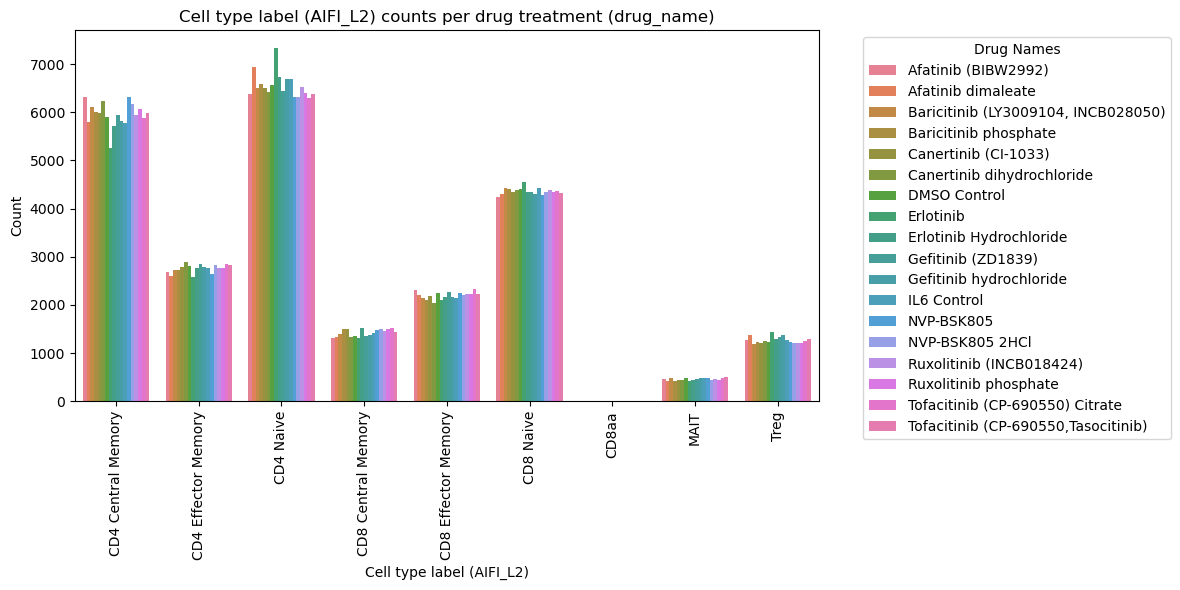

In [15]:
# bar plot:

plt.figure(figsize = (12, 6))
#x-axis is cell type labels AIFI_L2, y-axis is count, hue (grouping by) drug_name
sns.barplot(data = count_name_df, x = "AIFI_L2", y = "count", hue = "drug_name")
plt.xticks(rotation = 90)
plt.title("Cell type label (AIFI_L2) counts per drug treatment (drug_name)")
plt.xlabel("Cell type label (AIFI_L2)")
plt.ylabel("Count")

#moving the legend to be outside of the plot
plt.legend(title="Drug Names", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**The cell type CD8aa is significantly underrepresented and MAIT as well. This was seen above when the total counts of CD8aa was 25 and MAIT was 8262 (compared to the most annotations CD4 Naive with 118,058).**

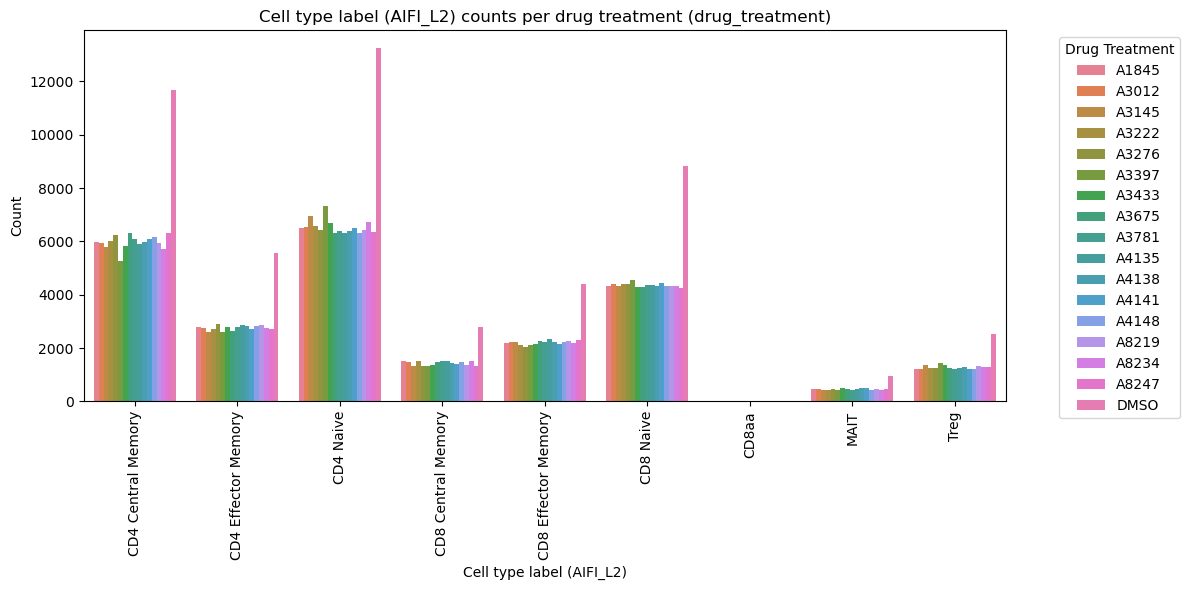

In [16]:
# bar plot:
# x-axis is cell type labels AIFI_L2
# y-axis is count
# hue, what we're grouping by, is drug_treatment

plt.figure(figsize = (12, 6))
sns.barplot(data = count_treatment_df, x = "AIFI_L2", y = "count", hue = "drug_treatment")
plt.xticks(rotation = 90)
plt.title("Cell type label (AIFI_L2) counts per drug treatment (drug_treatment)")
plt.xlabel("Cell type label (AIFI_L2)")
plt.ylabel("Count")

#moving the legend to be outside of the plot
plt.legend(title="Drug Treatment", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**The same trend as with drug name plot, the CD8aa and MAIT are underrepresented.**

**Here the DMSO has double the counts compared to the drug name plot - this is the same as what was seen above where all other treatments had 25,000 samples and DMSO had 50,000.**

## Visualizing the data through Heatmaps

In [17]:
# heatmap: requires a matrix

#converting the dataframe to a matrix
count_name_matrix = count_name_df.pivot_table(
    #"drug_name" will be the rows/index
    index = "drug_name",
    #"AIFI_L2" will be the columns (the cell labels)
    columns = "AIFI_L2",
    #"count" will determine the color intensity
    values = "count",
    #aggregate the "values" (count) by the sum
    aggfunc = "sum",
    fill_value = 0,
    #get rid of update warning
    observed = False
)

#looking at the first 5 rows of the new dataframe
count_name_matrix.head()

AIFI_L2,CD4 Central Memory,CD4 Effector Memory,CD4 Naive,CD8 Central Memory,CD8 Effector Memory,CD8 Naive,CD8aa,MAIT,Treg
drug_name,,,,,,,,,
Afatinib (BIBW2992),6312,2695,6370,1324,2311,4247,2,469,1270
Afatinib dimaleate,5793,2596,6949,1337,2216,4312,1,426,1370
"Baricitinib (LY3009104, INCB028050)",6107,2727,6510,1405,2140,4429,1,484,1197
Baricitinib phosphate,6005,2732,6583,1508,2105,4406,1,425,1235
Canertinib (CI-1033),5994,2785,6512,1502,2192,4344,0,450,1221


In [18]:
#converting the dataframe to a matrix for normalized counts
count_name_norm_matrix = count_name_df.pivot_table(
    #"drug_name" will be the rows/index
    index = "drug_name",
    #"AIFI_L2" will be the columns (the cell labels)
    columns = "AIFI_L2",
    #"normalized_count" will determine the color intensity
    values = "normalized_count",
    #aggregate the "values" (count) by the sum
    aggfunc = "sum",
    fill_value = 0,
    #get rid of update warning
    observed = False
)

#looking at the first 5 rows of the new dataframe
count_name_norm_matrix.head()

AIFI_L2,CD4 Central Memory,CD4 Effector Memory,CD4 Naive,CD8 Central Memory,CD8 Effector Memory,CD8 Naive,CD8aa,MAIT,Treg
drug_name,,,,,,,,,
Afatinib (BIBW2992),1.000000,0.932203,0.868439,0.869337,0.987607,0.934228,0.153846,0.934263,0.886253
Afatinib dimaleate,0.917776,0.897959,0.947376,0.877873,0.947009,0.948526,0.076923,0.848606,0.956036
"Baricitinib (LY3009104, INCB028050)",0.967522,0.943272,0.887526,0.922521,0.914530,0.974263,0.076923,0.964143,0.835311
Baricitinib phosphate,0.951362,0.945002,0.897478,0.990151,0.899573,0.969204,0.076923,0.846614,0.861828
Canertinib (CI-1033),0.949620,0.963334,0.887798,0.986211,0.936752,0.955565,0.000000,0.896414,0.852059


In [19]:
#converting the dataframe to a matrix for rescaled normalized counts
count_name_rescale_norm_matrix = count_name_df.pivot_table(
    #"drug_name" will be the rows/index
    index = "drug_name",
    #"AIFI_L2" will be the columns (the cell labels)
    columns = "AIFI_L2",
    #"normalized_count" will determine the color intensity
    values = "rescaled_count",
    #aggregate the "values" (count) by the sum
    aggfunc = "sum",
    fill_value = 0,
    #get rid of update warning
    observed = False
)

#looking at the first 5 rows of the new dataframe
count_name_rescale_norm_matrix.head()

AIFI_L2,CD4 Central Memory,CD4 Effector Memory,CD4 Naive,CD8 Central Memory,CD8 Effector Memory,CD8 Naive,CD8aa,MAIT,Treg
drug_name,,,,,,,,,
Afatinib (BIBW2992),1.000000,0.346667,0.064922,0.061321,0.903333,0.000000,0.083333,0.597561,0.309322
Afatinib dimaleate,0.502874,0.016667,0.625969,0.122642,0.586667,0.217391,0.000000,0.073171,0.733051
"Baricitinib (LY3009104, INCB028050)",0.803640,0.453333,0.200581,0.443396,0.333333,0.608696,0.000000,0.780488,0.000000
Baricitinib phosphate,0.705939,0.470000,0.271318,0.929245,0.216667,0.531773,0.000000,0.060976,0.161017
Canertinib (CI-1033),0.695402,0.646667,0.202519,0.900943,0.506667,0.324415,0.000000,0.365854,0.101695


In [20]:
#converting the dataframe to a matrix
count_treatment_matrix = count_treatment_df.pivot_table(
    #"drug_name" will be the rows
    index = "drug_treatment",
    #"AIFI_L2" will be the columns (the cell labels)
    columns = "AIFI_L2",
    #"count" will determine the color intensity
    values = "count",
    #aggregate the "values" (count) by the sum
    aggfunc = "sum",
    fill_value = 0,
    #get rid of update warning
    observed = False
)

#looking at the first 5 rows of the new dataframe
count_treatment_matrix.head()

AIFI_L2,CD4 Central Memory,CD4 Effector Memory,CD4 Naive,CD8 Central Memory,CD8 Effector Memory,CD8 Naive,CD8aa,MAIT,Treg
drug_treatment,,,,,,,,,
A1845,5994,2785,6512,1502,2192,4344,0,450,1221
A3012,5941,2767,6535,1463,2223,4386,3,463,1219
A3145,5793,2596,6949,1337,2216,4312,1,426,1370
A3222,6005,2732,6583,1508,2105,4406,1,425,1235
A3276,6237,2891,6424,1333,2040,4384,0,448,1243


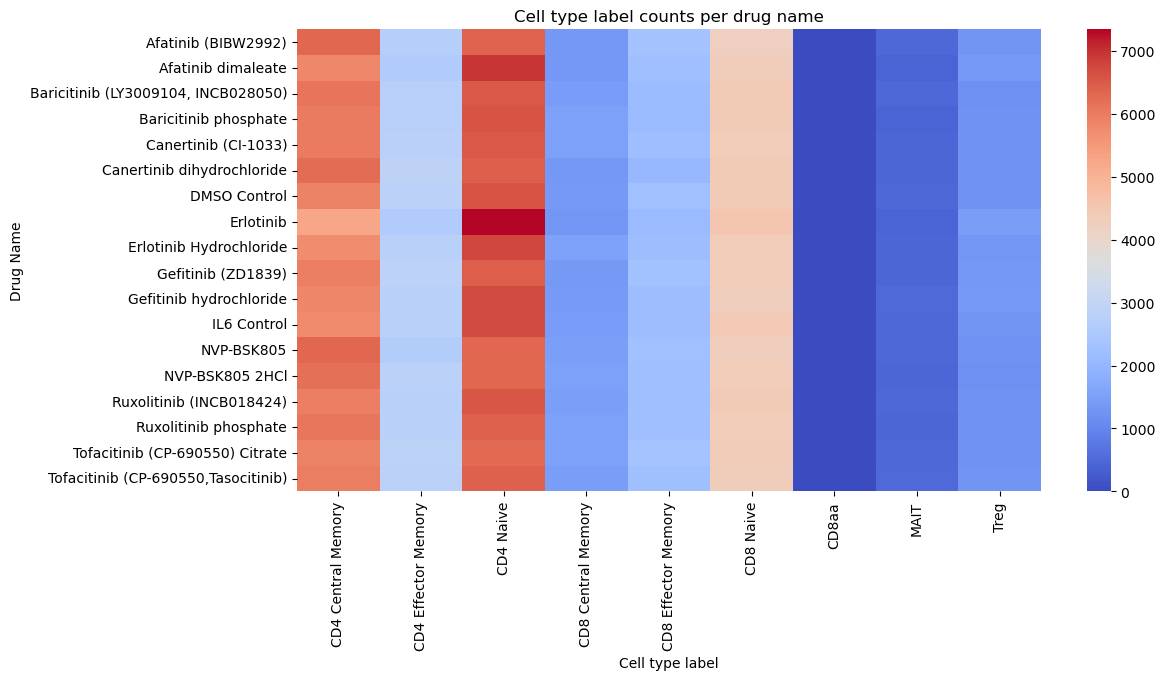

In [21]:
plt.figure(figsize = (12, 6))
sns.heatmap(data = count_name_matrix, cmap = "coolwarm")
plt.xticks(rotation = 90)
plt.title("Cell type label counts per drug name")
plt.xlabel("Cell type label")
plt.ylabel("Drug Name")
plt.show()

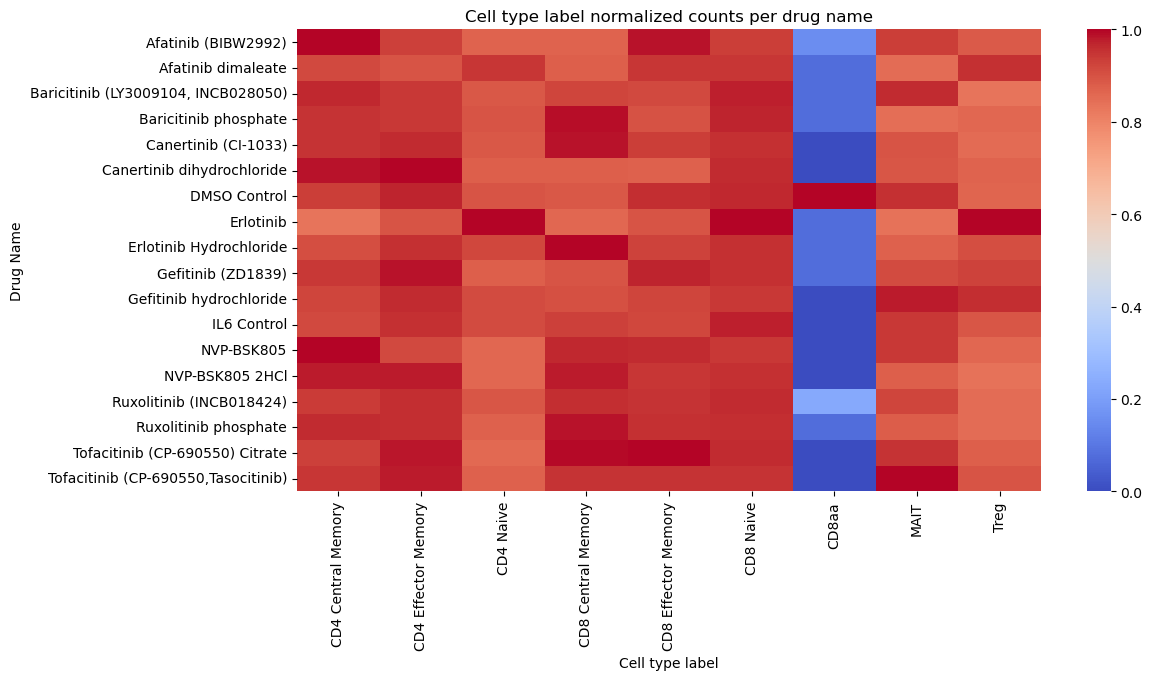

In [22]:
plt.figure(figsize = (12, 6))
sns.heatmap(data = count_name_norm_matrix, cmap = "coolwarm")
plt.xticks(rotation = 90)
plt.title("Cell type label normalized counts per drug name")
plt.xlabel("Cell type label")
plt.ylabel("Drug Name")
plt.show()

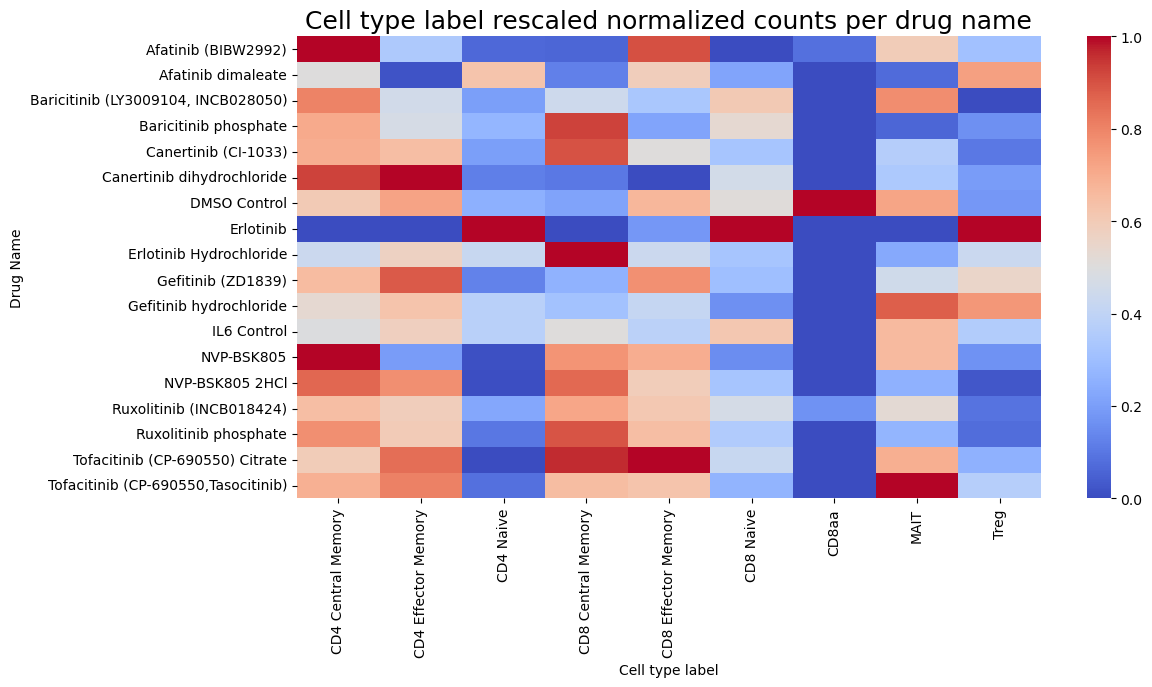

In [25]:
plt.figure(figsize = (12, 6))
sns.heatmap(data = count_name_rescale_norm_matrix, cmap = "coolwarm")
plt.xticks(rotation = 90)
plt.title("Cell type label rescaled normalized counts per drug name", fontsize=18)
plt.xlabel("Cell type label", fontsize=18)
plt.ylabel("Drug Name")
plt.show() 

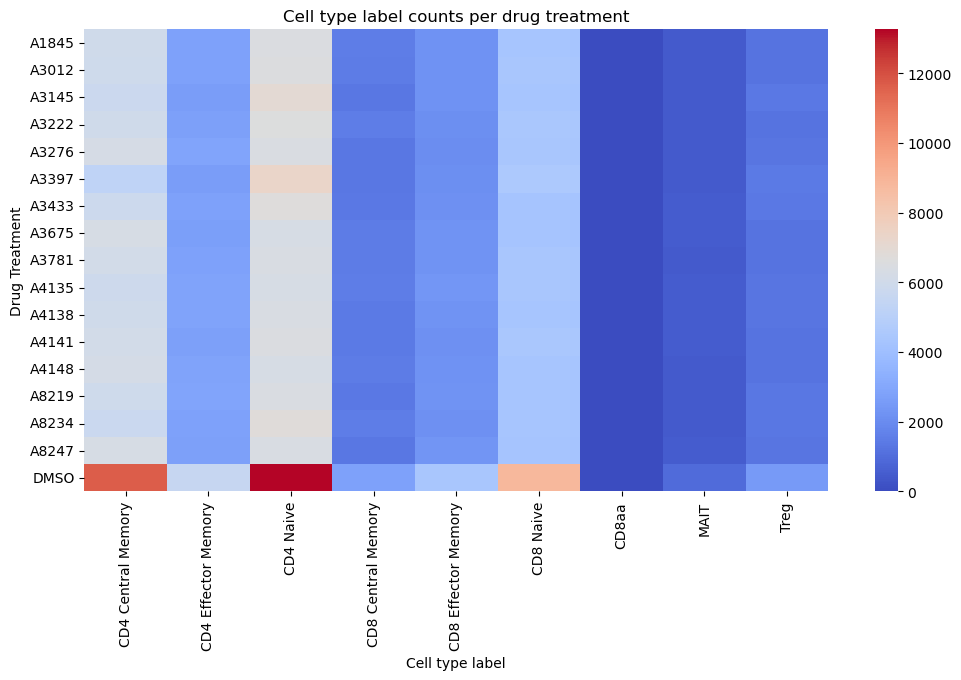

In [24]:
plt.figure(figsize = (12, 6))
sns.heatmap(data = count_treatment_matrix, cmap = "coolwarm")
plt.xticks(rotation = 90)
plt.title("Cell type label counts per drug treatment")
plt.xlabel("Cell type label")
plt.ylabel("Drug Treatment")
plt.show()

**Like seen in the bar plots, CD8aa and MAIT are underpresented.**